<a href="https://colab.research.google.com/github/AISHWARYAARULSELVAN/IPCV/blob/main/EXP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving exp_4.png to exp_4 (1).png


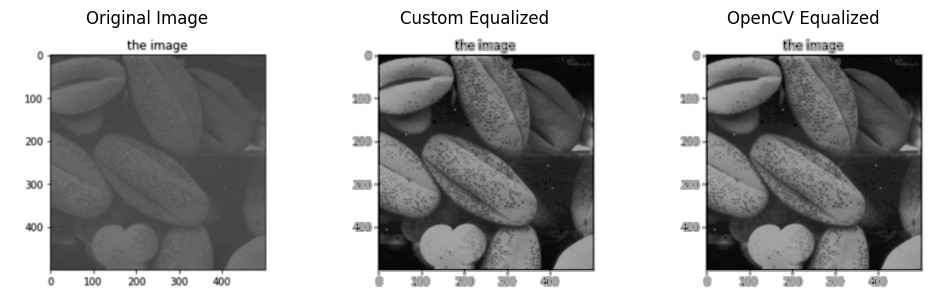

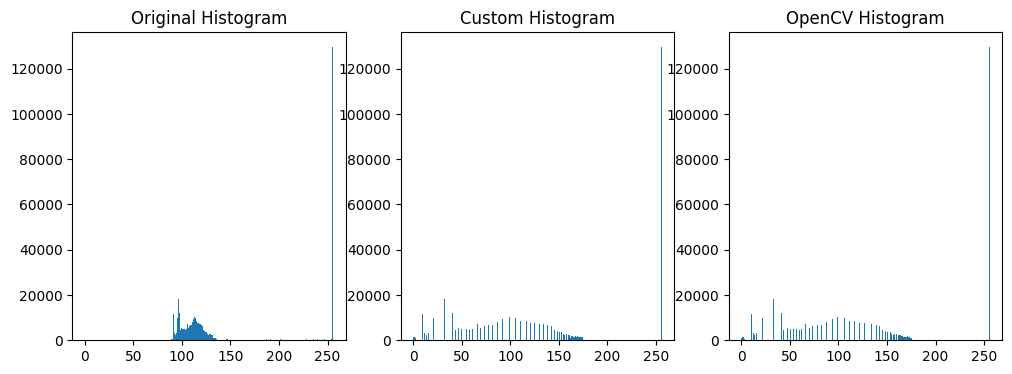

In [2]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Histogram Equalization Function
def equalize_hist(image, L=256):

    intensity_levels, counts = np.unique(image, return_counts=True)

    total_pixels = image.size

    pdf = counts / total_pixels

    cdf = np.cumsum(pdf)

    transform = np.floor((L - 1) * cdf).astype(np.uint8)

    mapping = dict(zip(intensity_levels, transform))

    equalized_image = np.vectorize(mapping.get)(image)

    return equalized_image.astype(np.uint8)

# Read uploaded image
filename = list(uploaded.keys())[0]

image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found")
    exit()

# Histogram Equalization
custom_image = equalize_hist(image)

opencv_image = cv2.equalizeHist(image)

# Display Images
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(custom_image, cmap='gray')
plt.title("Custom Equalized")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(opencv_image, cmap='gray')
plt.title("OpenCV Equalized")
plt.axis("off")

plt.show()

# Display Histograms
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(image.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,3,2)
plt.hist(custom_image.ravel(), bins=256, range=[0,256])
plt.title("Custom Histogram")

plt.subplot(1,3,3)
plt.hist(opencv_image.ravel(), bins=256, range=[0,256])
plt.title("OpenCV Histogram")

plt.show()